# M08 vs M09 evaluation

This notebook evaluates whether replacing the global average pooling of M08 with the M09 multi-slot temporal attention pooling improves CBC parameter regression.

Comparison:

- **M08**: residual dilated encoder + `AdaptiveAvgPool1d(1)`
- **M09**: same residual dilated encoder + multi-slot temporal attention pooling

Use the same 500k dataset, same split, same seed, same loss, same optimizer settings, and same evaluation splits.

Primary question:

> Does M09 improve point-estimation accuracy and error tails relative to M08 enough to justify the more complex pooling mechanism?


## 1. Imports and paths

In [1]:
from pathlib import Path
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

DATA_ROOT = Path("/data/vserrano/cbc_pe_data")
RESULTS_ROOT = DATA_ROOT / "results"
CHECKPOINT_ROOT = DATA_ROOT / "models" / "checkpoints"
PROCESSED_ROOT = DATA_ROOT / "processed"

DATASET_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"
DATASET_RESULTS_ROOT = RESULTS_ROOT / DATASET_ID
DATASET_CHECKPOINT_ROOT = CHECKPOINT_ROOT / DATASET_ID

PROJECT_ROOT = Path("/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/")
if PROJECT_ROOT.exists() and str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

LABEL_NAMES = ["chirp_mass", "total_mass", "chi_eff"]
SPLITS = ["val", "cal", "test"]

print("DATASET_RESULTS_ROOT:", DATASET_RESULTS_ROOT, DATASET_RESULTS_ROOT.exists())
print("DATASET_CHECKPOINT_ROOT:", DATASET_CHECKPOINT_ROOT, DATASET_CHECKPOINT_ROOT.exists())
print("PROJECT_ROOT:", PROJECT_ROOT, PROJECT_ROOT.exists())

DATASET_RESULTS_ROOT: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000 True
DATASET_CHECKPOINT_ROOT: /data/vserrano/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000 True
PROJECT_ROOT: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe True


## 2. Resolve files

Review the selected files before continuing. The filename patterns are flexible to tolerate small naming differences.

In [2]:
def resolve_file(root: Path, patterns, description: str) -> Path:
    if isinstance(patterns, (str, Path)):
        patterns = [patterns]

    matches = []
    for pattern in patterns:
        matches.extend(root.glob(str(pattern)))

    matches = sorted(set(matches), key=lambda p: p.stat().st_mtime)

    if not matches:
        raise FileNotFoundError(
            f"Could not find {description} in {root}.\n"
            f"Patterns tried: {[str(p) for p in patterns]}"
        )

    print(f"\n{description}:")
    for path in matches:
        print("  ", path.name)

    selected = matches[-1]
    print("Selected:", selected.name)
    return selected


RUNS = {
    "M08": {
        "label": "M08 avg pooling",
        "prediction_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz",


        ],
        "history_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_history.npz",

        ],
        "checkpoint_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_checkpoint.pt",

        ],
    },
    "M09": {
        "label": "M09 multi-slot attention pooling",
        "prediction_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention_M09_multiattn_k4_sd32_emb64_d124_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz",
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention*M09*seed123*val_cal_test*predictions_embeddings.npz",
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention*seed123*predictions_embeddings.npz",
        ],
        "history_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention_M09_multiattn_k4_sd32_emb64_d124_bs256_MSELoss_seed123_history.npz",
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention*M09*seed123*history.npz",
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention*seed123*history.npz",
        ],
        "checkpoint_patterns": [
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention_M09_multiattn_k4_sd32_emb64_d124_bs256_MSELoss_seed123_checkpoint.pt",
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention*M09*seed123*checkpoint.pt",
            f"{DATASET_ID}_SimpleCNN_ResidualDilatedMultiAttention*seed123*checkpoint.pt",
        ],
    },
}

for run_id, run in RUNS.items():
    run["prediction_path"] = resolve_file(DATASET_RESULTS_ROOT, run["prediction_patterns"], f"{run_id} prediction file")
    run["history_path"] = resolve_file(DATASET_RESULTS_ROOT, run["history_patterns"], f"{run_id} history file")
    run["checkpoint_path"] = resolve_file(DATASET_CHECKPOINT_ROOT, run["checkpoint_patterns"], f"{run_id} checkpoint")

for run_id, run in RUNS.items():
    print(run_id, "prediction:", run["prediction_path"].name)
    print(run_id, "history:   ", run["history_path"].name)
    print(run_id, "checkpoint:", run["checkpoint_path"].name)


M08 prediction file:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz

M08 history file:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_history.npz
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_history.npz

M08 checkpoint:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_checkpoint.pt
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_checkpoint.pt

M09 prediction file:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilatedMultiAttention_M09_multiattn_k4_

## 3. Load label statistics and prediction files

In [3]:
LABEL_STATS_PATH = resolve_file(
    PROCESSED_ROOT / DATASET_ID,
    [
        f"{DATASET_ID}_label_stats_train_only_train400000_val40000_cal30000_test30000_seed123.npz",
        f"{DATASET_ID}*label_stats*seed123.npz",
    ],
    "label statistics",
)

with np.load(LABEL_STATS_PATH) as stats:
    y_mean = np.asarray(stats["y_mean"], dtype=float)
    y_std = np.asarray(stats["y_std"], dtype=float)

print("y_mean:", y_mean)
print("y_std:", y_std)


def load_prediction_file(path: Path):
    out = {}
    with np.load(path, allow_pickle=True) as data:
        print(f"\n{path.name}")
        for key in sorted(data.files):
            arr = np.asarray(data[key])
            print(f"  {key:24s} shape={str(arr.shape):16s} dtype={arr.dtype}")
            out[key] = arr
    return out


RAW = {run_id: load_prediction_file(run["prediction_path"]) for run_id, run in RUNS.items()}


label statistics:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_label_stats_train_only_train400000_val40000_cal30000_test30000_seed123.npz
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_label_stats_train_only_train400000_val40000_cal30000_test30000_seed123.npz
y_mean: [3.74526215e+01 9.49739685e+01 1.02269521e-03]
y_std: [16.48472214 34.65016556  0.44085518]

bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_val_cal_test_predictions_embeddings.npz
  available_splits         shape=(3,)             dtype=<U4
  checkpoint_file          shape=()               dtype=<U166
  dataset_path             shape=()               dtype=<U86
  emb_cal                  shape=(30000, 64)      dtype=float32
  emb_test                 shape=(30000, 64)      dtype=float32
  emb_val                  shape=(40000, 64)      dtype=float32
  idx_cal                  shape=(30000,)         dtype=int64
  idx_test                 shape=(30000

## 4. Align splits by HDF5 indices

In [4]:
def align_runs_for_split(raw_by_run, split, reference_run="M08"):
    required = [f"idx_{split}", f"pred_{split}", f"y_{split}", f"emb_{split}"]

    for run_id, data in raw_by_run.items():
        missing = [key for key in required if key not in data]
        if missing:
            raise KeyError(f"{run_id} is missing keys for {split}: {missing}")

    common_idx = None
    for data in raw_by_run.values():
        idx = np.asarray(data[f"idx_{split}"], dtype=np.int64)
        common_idx = idx if common_idx is None else np.intersect1d(common_idx, idx)

    common_idx = np.sort(common_idx)
    aligned = {}

    for run_id, data in raw_by_run.items():
        idx = np.asarray(data[f"idx_{split}"], dtype=np.int64)
        order = np.argsort(idx)
        idx_sorted = idx[order]

        positions = np.searchsorted(idx_sorted, common_idx)
        if not np.array_equal(idx_sorted[positions], common_idx):
            raise RuntimeError(f"Alignment failure for {run_id}, split={split}")

        aligned[run_id] = {
            "idx": common_idx,
            "pred": np.asarray(data[f"pred_{split}"])[order][positions],
            "y": np.asarray(data[f"y_{split}"])[order][positions],
            "emb": np.asarray(data[f"emb_{split}"])[order][positions],
        }

    y_ref = aligned[reference_run]["y"]
    for run_id in aligned:
        if not np.allclose(aligned[run_id]["y"], y_ref, rtol=1e-5, atol=1e-5):
            raise AssertionError(f"Targets do not agree after alignment: {reference_run} vs {run_id}")

    return aligned


ALIGNED = {}
for split in SPLITS:
    ALIGNED[split] = align_runs_for_split(RAW, split)
    print(f"{split:5s}: {len(ALIGNED[split]['M08']['idx']):,} common samples")

val  : 40,000 common samples
cal  : 30,000 common samples
test : 30,000 common samples


## 5. Regression metrics

In [5]:
def inverse_standardize(y):
    return y * y_std + y_mean


def regression_metrics(y_true, y_pred, run_id, split, space):
    residual = y_pred - y_true
    abs_error = np.abs(residual)

    mse = np.mean(residual**2, axis=0)
    rmse = np.sqrt(mse)
    mae = np.mean(abs_error, axis=0)
    bias = np.mean(residual, axis=0)
    residual_std = np.std(residual, axis=0)
    median_ae = np.median(abs_error, axis=0)

    ss_res = np.sum(residual**2, axis=0)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0, keepdims=True)) ** 2, axis=0)
    r2 = 1.0 - ss_res / ss_tot

    rows = []
    for j, label in enumerate(LABEL_NAMES):
        rows.append({
            "run_id": run_id,
            "split": split,
            "space": space,
            "label": label,
            "MSE": float(mse[j]),
            "RMSE": float(rmse[j]),
            "MAE": float(mae[j]),
            "bias": float(bias[j]),
            "median_abs_error": float(median_ae[j]),
            "residual_std": float(residual_std[j]),
            "R2": float(r2[j]),
        })
    return rows


metric_rows = []

for split in SPLITS:
    y_true_std = ALIGNED[split]["M08"]["y"]
    y_true_phys = inverse_standardize(y_true_std)

    for run_id in RUNS:
        pred_std = ALIGNED[split][run_id]["pred"]
        pred_phys = inverse_standardize(pred_std)

        metric_rows.extend(regression_metrics(y_true_std, pred_std, run_id, split, "standardized"))
        metric_rows.extend(regression_metrics(y_true_phys, pred_phys, run_id, split, "physical"))

metrics_df = pd.DataFrame(metric_rows)

global_metrics_df = (
    metrics_df
    .groupby(["run_id", "split", "space"], as_index=False)
    .agg(
        global_MSE=("MSE", "mean"),
        global_RMSE=("RMSE", "mean"),
        global_MAE=("MAE", "mean"),
        mean_R2=("R2", "mean"),
    )
)

display(global_metrics_df.query("space == 'standardized'"))
display(metrics_df.query("split == 'test' and space == 'standardized'").sort_values(["label", "run_id"]))

,run_id,split,space,global_MSE,global_RMSE,global_MAE,mean_R2
1,M08,cal,standardized,0.115611,0.333401,0.243953,0.884359
3,M08,test,standardized,0.116352,0.334414,0.244785,0.883717
5,M08,val,standardized,0.116115,0.334060,0.244682,0.883949
7,M09,cal,standardized,0.113392,0.330174,0.240873,0.886580
9,M09,test,standardized,0.113651,0.330422,0.241269,0.886418
11,M09,val,standardized,0.114245,0.331242,0.242532,0.885817


,run_id,split,space,label,MSE,RMSE,MAE,bias,median_abs_error,residual_std,R2
26,M08,test,standardized,chi_eff,0.182919,0.427691,0.321956,-0.011796,0.251846,0.427528,0.816637
32,M09,test,standardized,chi_eff,0.178783,0.422827,0.319684,0.014700,0.251389,0.422573,0.820784
24,M08,test,standardized,chirp_mass,0.092243,0.303716,0.211312,-0.007336,0.141675,0.303627,0.908286
30,M09,test,standardized,chirp_mass,0.091000,0.301663,0.208088,-0.001031,0.136211,0.301662,0.909522
25,M08,test,standardized,total_mass,0.073894,0.271834,0.201088,-0.017916,0.152958,0.271244,0.926229
31,M09,test,standardized,total_mass,0.071169,0.266775,0.196034,-0.012086,0.147811,0.266502,0.928949


## 6. M09 vs M08 differences

For error metrics, negative values mean M09 improves over M08.

In [6]:
def difference_table(metrics, split="test", space="standardized"):
    sub = metrics.query("split == @split and space == @space")
    pivot = sub.pivot(index="label", columns="run_id")

    rows = []
    for label in LABEL_NAMES:
        row = {"label": label}

        for metric in ["MSE", "RMSE", "MAE"]:
            m08 = float(pivot.loc[label, (metric, "M08")])
            m09 = float(pivot.loc[label, (metric, "M09")])
            row[f"{metric}_M08"] = m08
            row[f"{metric}_M09"] = m09
            row[f"{metric}_delta_pct"] = 100 * (m09 - m08) / m08

        for metric in ["R2", "bias"]:
            m08 = float(pivot.loc[label, (metric, "M08")])
            m09 = float(pivot.loc[label, (metric, "M09")])
            row[f"{metric}_M08"] = m08
            row[f"{metric}_M09"] = m09
            row[f"{metric}_delta"] = m09 - m08

        rows.append(row)

    return pd.DataFrame(rows)


test_difference_df = difference_table(metrics_df, split="test", space="standardized")
display(test_difference_df)

global_test = global_metrics_df.query("split == 'test' and space == 'standardized'").set_index("run_id")

global_difference_df = pd.DataFrame([{
    "global_MSE_M08": global_test.loc["M08", "global_MSE"],
    "global_MSE_M09": global_test.loc["M09", "global_MSE"],
    "global_MSE_delta_pct": 100 * (global_test.loc["M09", "global_MSE"] - global_test.loc["M08", "global_MSE"]) / global_test.loc["M08", "global_MSE"],
    "global_MAE_M08": global_test.loc["M08", "global_MAE"],
    "global_MAE_M09": global_test.loc["M09", "global_MAE"],
    "global_MAE_delta_pct": 100 * (global_test.loc["M09", "global_MAE"] - global_test.loc["M08", "global_MAE"]) / global_test.loc["M08", "global_MAE"],
}])

display(global_difference_df)

,label,MSE_M08,MSE_M09,MSE_delta_pct,RMSE_M08,RMSE_M09,RMSE_delta_pct,MAE_M08,MAE_M09,MAE_delta_pct,R2_M08,R2_M09,R2_delta,bias_M08,bias_M09,bias_delta
0,chirp_mass,0.092243,0.091000,-1.347565,0.303716,0.301663,-0.676066,0.211312,0.208088,-1.525661,0.908286,0.909522,0.001236,-0.007336,-0.001031,0.006305
1,total_mass,0.073894,0.071169,-3.687344,0.271834,0.266775,-1.860987,0.201088,0.196034,-2.513063,0.926229,0.928949,0.002720,-0.017916,-0.012086,0.005830
2,chi_eff,0.182919,0.178783,-2.261583,0.427691,0.422827,-1.137258,0.321956,0.319684,-0.705827,0.816637,0.820784,0.004147,-0.011796,0.014700,0.026496


,global_MSE_M08,global_MSE_M09,global_MSE_delta_pct,global_MAE_M08,global_MAE_M09,global_MAE_delta_pct
0,0.116352,0.113651,-2.321867,0.244785,0.241269,-1.436609


## 7. Regression-to-the-mean diagnostics

In [7]:
def slope_diagnostics(y_true, y_pred, run_id, split):
    rows = []

    for j, label in enumerate(LABEL_NAMES):
        true = y_true[:, j]
        pred = y_pred[:, j]

        slope, intercept = np.polyfit(true, pred, deg=1)
        corr = np.corrcoef(true, pred)[0, 1]

        q01_true, q99_true = np.quantile(true, [0.01, 0.99])
        q01_pred, q99_pred = np.quantile(pred, [0.01, 0.99])

        rows.append({
            "run_id": run_id,
            "split": split,
            "label": label,
            "slope": float(slope),
            "intercept": float(intercept),
            "correlation": float(corr),
            "std_ratio_pred_over_true": float(np.std(pred) / np.std(true)),
            "q01_q99_ratio_pred_over_true": float((q99_pred - q01_pred) / (q99_true - q01_true)),
        })

    return rows


slope_rows = []

for split in SPLITS:
    y_true = ALIGNED[split]["M08"]["y"]

    for run_id in RUNS:
        slope_rows.extend(slope_diagnostics(y_true, ALIGNED[split][run_id]["pred"], run_id, split))

slope_df = pd.DataFrame(slope_rows)

display(slope_df.query("split == 'test'").sort_values(["label", "run_id"]))

slope_pivot = slope_df.query("split == 'test'").pivot(index="label", columns="run_id")

slope_delta_rows = []
for label in LABEL_NAMES:
    slope_delta_rows.append({
        "label": label,
        "slope_M08": slope_pivot.loc[label, ("slope", "M08")],
        "slope_M09": slope_pivot.loc[label, ("slope", "M09")],
        "slope_delta": slope_pivot.loc[label, ("slope", "M09")] - slope_pivot.loc[label, ("slope", "M08")],
        "std_ratio_M08": slope_pivot.loc[label, ("std_ratio_pred_over_true", "M08")],
        "std_ratio_M09": slope_pivot.loc[label, ("std_ratio_pred_over_true", "M09")],
        "std_ratio_delta": slope_pivot.loc[label, ("std_ratio_pred_over_true", "M09")] - slope_pivot.loc[label, ("std_ratio_pred_over_true", "M08")],
    })

slope_delta_df = pd.DataFrame(slope_delta_rows)
display(slope_delta_df)

,run_id,split,label,slope,intercept,correlation,std_ratio_pred_over_true,q01_q99_ratio_pred_over_true
14,M08,test,chi_eff,0.811833,-0.010266,0.903774,0.898270,0.857422
17,M09,test,chi_eff,0.780016,0.016489,0.907343,0.859670,0.814835
12,M08,test,chirp_mass,0.872785,-0.006840,0.953860,0.915003,0.909437
15,M09,test,chirp_mass,0.874926,-0.000544,0.954435,0.916695,0.905521
13,M08,test,total_mass,0.893434,-0.017418,0.963236,0.927534,0.899667
16,M09,test,total_mass,0.899396,-0.011615,0.964421,0.932575,0.899692


,label,slope_M08,slope_M09,slope_delta,std_ratio_M08,std_ratio_M09,std_ratio_delta
0,chirp_mass,0.872785,0.874926,0.002141,0.915003,0.916695,0.001692
1,total_mass,0.893434,0.899396,0.005962,0.927534,0.932575,0.005041
2,chi_eff,0.811833,0.780016,-0.031817,0.898270,0.859670,-0.038600


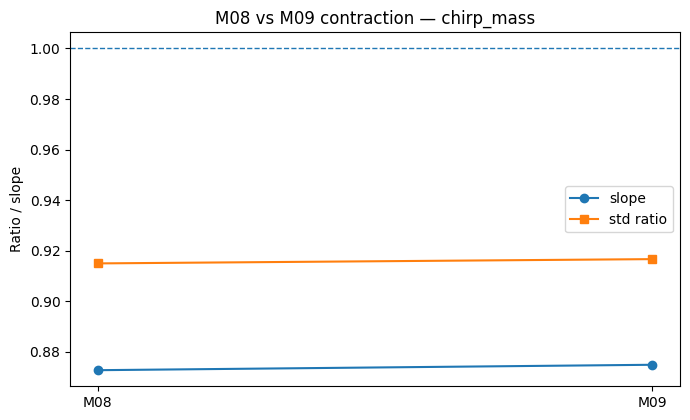

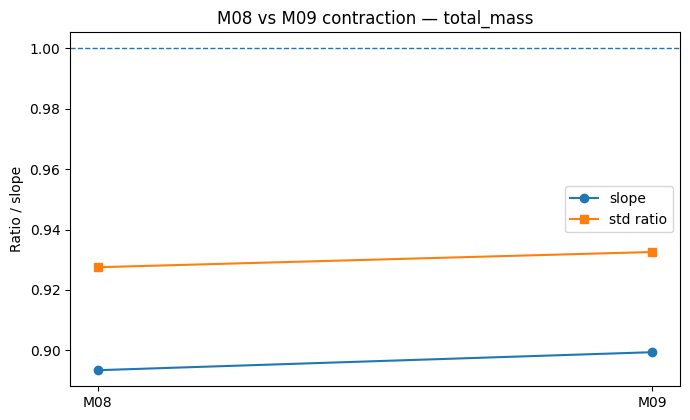

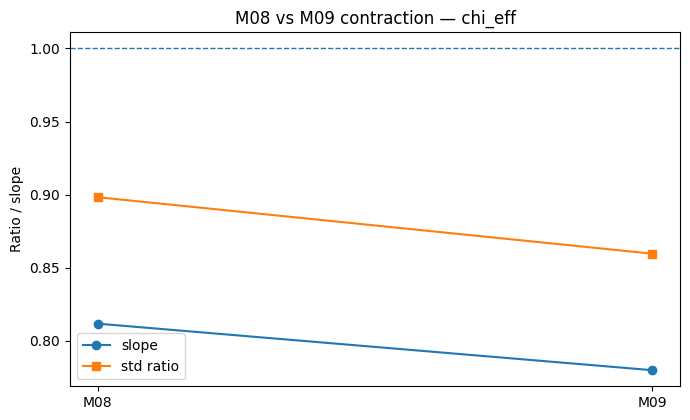

In [8]:
for label in LABEL_NAMES:
    sub = slope_df.query("split == 'test' and label == @label").set_index("run_id").loc[["M08", "M09"]]

    plt.figure(figsize=(7.0, 4.3))
    plt.plot(sub.index, sub["slope"], marker="o", label="slope")
    plt.plot(sub.index, sub["std_ratio_pred_over_true"], marker="s", label="std ratio")
    plt.axhline(1.0, linestyle="--", linewidth=1)
    plt.ylabel("Ratio / slope")
    plt.title(f"M08 vs M09 contraction — {label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 8. Physical absolute-error quantiles

In [9]:
QUANTILES = [0.50, 0.90, 0.95, 0.99]
quantile_rows = []

for split in SPLITS:
    y_true_phys = inverse_standardize(ALIGNED[split]["M08"]["y"])

    for run_id in RUNS:
        pred_phys = inverse_standardize(ALIGNED[split][run_id]["pred"])
        ae = np.abs(pred_phys - y_true_phys)

        for j, label in enumerate(LABEL_NAMES):
            for q in QUANTILES:
                quantile_rows.append({
                    "run_id": run_id,
                    "split": split,
                    "label": label,
                    "quantile": q,
                    "absolute_error": float(np.quantile(ae[:, j], q)),
                })

quantiles_df = pd.DataFrame(quantile_rows)

test_quantile_df = (
    quantiles_df.query("split == 'test'")
    .pivot_table(index=["label", "quantile"], columns="run_id", values="absolute_error")
    .reset_index()
)

test_quantile_df["M09_vs_M08_pct"] = 100 * (test_quantile_df["M09"] - test_quantile_df["M08"]) / test_quantile_df["M08"]

display(test_quantile_df)

run_id,label,quantile,M08,M09,M09_vs_M08_pct
0,chi_eff,0.500000,0.111028,0.110826,-0.181302
1,chi_eff,0.900000,0.300427,0.298029,-0.798206
2,chi_eff,0.950000,0.379371,0.373106,-1.651254
3,chi_eff,0.990000,0.566387,0.568263,0.331110
4,chirp_mass,0.500000,2.335467,2.245406,-3.856213
5,chirp_mass,0.900000,8.031778,7.910862,-1.505463
6,chirp_mass,0.950000,10.439767,10.372705,-0.642370
7,chirp_mass,0.990000,17.008786,16.945677,-0.371035
8,total_mass,0.500000,5.300006,5.121672,-3.364790
9,total_mass,0.900000,15.019311,14.824495,-1.297106


## 9. Paired bootstrap on test-set metric deltas

In [10]:
def paired_bootstrap_metric_delta(y_true, pred_a, pred_b, metric="mse", n_boot=2000, seed=123):
    rng = np.random.default_rng(seed)
    n = y_true.shape[0]
    n_labels = y_true.shape[1]

    deltas = np.empty((n_boot, n_labels), dtype=float)

    err_a = pred_a - y_true
    err_b = pred_b - y_true

    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)

        if metric == "mse":
            va = np.mean(err_a[idx] ** 2, axis=0)
            vb = np.mean(err_b[idx] ** 2, axis=0)
        elif metric == "mae":
            va = np.mean(np.abs(err_a[idx]), axis=0)
            vb = np.mean(np.abs(err_b[idx]), axis=0)
        else:
            raise ValueError(metric)

        deltas[i] = vb - va

    return deltas


y_true_test = ALIGNED["test"]["M08"]["y"]
pred_m08_test = ALIGNED["test"]["M08"]["pred"]
pred_m09_test = ALIGNED["test"]["M09"]["pred"]

bootstrap_rows = []

for metric in ["mse", "mae"]:
    deltas = paired_bootstrap_metric_delta(y_true_test, pred_m08_test, pred_m09_test, metric=metric, n_boot=2000, seed=123)

    if metric == "mse":
        point = np.mean((pred_m09_test - y_true_test) ** 2, axis=0) - np.mean((pred_m08_test - y_true_test) ** 2, axis=0)
    else:
        point = np.mean(np.abs(pred_m09_test - y_true_test), axis=0) - np.mean(np.abs(pred_m08_test - y_true_test), axis=0)

    for j, label in enumerate(LABEL_NAMES):
        bootstrap_rows.append({
            "metric": metric.upper(),
            "label": label,
            "delta_M09_minus_M08": float(point[j]),
            "ci95_low": float(np.quantile(deltas[:, j], 0.025)),
            "ci95_high": float(np.quantile(deltas[:, j], 0.975)),
            "prob_delta_below_zero": float(np.mean(deltas[:, j] < 0)),
        })

bootstrap_df = pd.DataFrame(bootstrap_rows)
display(bootstrap_df)

,metric,label,delta_M09_minus_M08,ci95_low,ci95_high,prob_delta_below_zero
0,MSE,chirp_mass,-0.001243,-0.002538,-0.000020,0.976500
1,MSE,total_mass,-0.002725,-0.003826,-0.001629,1.000000
2,MSE,chi_eff,-0.004137,-0.006629,-0.001577,0.998500
3,MAE,chirp_mass,-0.003224,-0.004435,-0.001961,1.000000
4,MAE,total_mass,-0.005053,-0.006291,-0.003861,1.000000
5,MAE,chi_eff,-0.002272,-0.004282,-0.000192,0.985000


## 10. Per-event win rates and disagreement

In [11]:
ae_m08 = np.abs(pred_m08_test - y_true_test)
ae_m09 = np.abs(pred_m09_test - y_true_test)

win_rows = []
for j, label in enumerate(LABEL_NAMES):
    disagreement = pred_m09_test[:, j] - pred_m08_test[:, j]

    win_rows.append({
        "label": label,
        "M08_win_rate": float(np.mean(ae_m08[:, j] < ae_m09[:, j])),
        "M09_win_rate": float(np.mean(ae_m09[:, j] < ae_m08[:, j])),
        "tie_rate": float(np.mean(ae_m08[:, j] == ae_m09[:, j])),
        "prediction_difference_mean": float(np.mean(disagreement)),
        "prediction_difference_std": float(np.std(disagreement)),
        "prediction_difference_q95_abs": float(np.quantile(np.abs(disagreement), 0.95)),
    })

win_rate_df = pd.DataFrame(win_rows)
display(win_rate_df)

,label,M08_win_rate,M09_win_rate,tie_rate,prediction_difference_mean,prediction_difference_std,prediction_difference_q95_abs
0,chirp_mass,0.487800,0.512200,0.000000,0.006305,0.120346,0.240781
1,total_mass,0.478067,0.521933,0.000000,0.005830,0.119649,0.239866
2,chi_eff,0.497867,0.502133,0.000000,0.026496,0.202344,0.401207


## 11. Training histories and checkpoint metadata

bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_batchslices_bs256_MSELoss_seed123_history.npz ['epoch_time', 'train_loss', 'train_time', 'val_loss', 'val_time']
bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilatedMultiAttention_M09_multiattn_k4_sd32_emb64_d124_bs256_MSELoss_seed123_history.npz ['epoch_time', 'train_loss', 'train_time', 'val_loss', 'val_time']


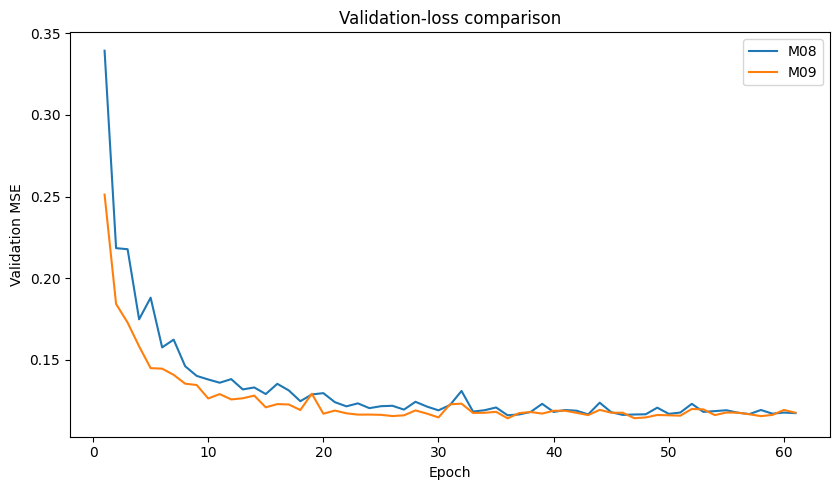

,run_id,best_epoch,stop_epoch,best_val_loss,final_train_loss,final_val_loss
0,M08,36,61,0.116116,0.108771,0.117426
1,M09,36,61,0.114245,0.097939,0.117672


In [12]:
def load_history(path):
    with np.load(path, allow_pickle=True) as data:
        out = {key: np.asarray(data[key]) for key in data.files}
    print(path.name, sorted(out))
    return out


def first_existing(mapping, candidates):
    for key in candidates:
        if key in mapping:
            return np.asarray(mapping[key])
    return None


HISTORIES = {run_id: load_history(run["history_path"]) for run_id, run in RUNS.items()}

history_rows = []

plt.figure(figsize=(8.5, 5.0))

for run_id, history in HISTORIES.items():
    train_loss = first_existing(history, ["train_loss", "train_losses", "loss_train"])
    val_loss = first_existing(history, ["val_loss", "val_losses", "loss_val"])

    if train_loss is None or val_loss is None:
        print(f"Missing loss keys for {run_id}")
        continue

    best_idx = int(np.nanargmin(val_loss))
    best_epoch = best_idx + 1
    stop_epoch = len(val_loss)

    history_rows.append({
        "run_id": run_id,
        "best_epoch": best_epoch,
        "stop_epoch": stop_epoch,
        "best_val_loss": float(val_loss[best_idx]),
        "final_train_loss": float(train_loss[-1]),
        "final_val_loss": float(val_loss[-1]),
    })

    epochs = np.arange(1, len(val_loss) + 1)
    plt.plot(epochs, val_loss, label=run_id)

plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Validation-loss comparison")
plt.legend()
plt.tight_layout()
plt.show()

history_summary_df = pd.DataFrame(history_rows)
display(history_summary_df)

In [13]:
checkpoint_rows = []

try:
    import torch

    for run_id, run in RUNS.items():
        checkpoint = torch.load(run["checkpoint_path"], map_location="cpu")

        model_config = checkpoint.get("model_config", {})
        model_kwargs = (
            model_config.get("kwargs")
            or model_config.get("model_kwargs")
            or checkpoint.get("model_kwargs")
            or {}
        )

        checkpoint_rows.append({
            "run_id": run_id,
            "checkpoint_name": run["checkpoint_path"].name,
            "saved_epoch": checkpoint.get("epoch", np.nan),
            "best_val_loss": checkpoint.get("best_val_loss", np.nan),
            "architecture": model_config.get("architecture"),
            "class_name": model_config.get("class_name"),
            "training_seed": model_config.get("training_seed", checkpoint.get("training_seed")),
            "split_seed": model_config.get("split_seed", checkpoint.get("split_seed")),
            "dilations": model_kwargs.get("dilations"),
            "embedding_dim": model_kwargs.get("embedding_dim"),
            "attention_slots": model_kwargs.get("attention_slots"),
            "attention_hidden": model_kwargs.get("attention_hidden"),
            "attention_dropout": model_kwargs.get("attention_dropout"),
            "slot_dim": model_kwargs.get("slot_dim"),
        })

    checkpoint_df = pd.DataFrame(checkpoint_rows)
    display(checkpoint_df)

except Exception as exc:
    print("Checkpoint inspection skipped or failed:")
    print(type(exc).__name__, exc)
    checkpoint_df = pd.DataFrame()

,run_id,checkpoint_name,saved_epoch,best_val_loss,architecture,class_name,training_seed,split_seed,dilations,embedding_dim,attention_slots,attention_hidden,attention_dropout,slot_dim
0,M08,bbh_processed_4s_seobnrv4opt_snr10-25_n500_000...,36,0.116116,SimpleCNN_ResidualDilated,SimpleCNN_ResidualDilated,123,123,"[1, 2, 4]",64,NaN,NaN,NaN,NaN
1,M09,bbh_processed_4s_seobnrv4opt_snr10-25_n500_000...,36,0.114245,M09_multiattn_k4_sd32_emb64_d124,SimpleCNN_ResidualDilatedMultiAttention,123,123,"[1, 2, 4]",64,4.000000,64.000000,0.000000,32.000000


## 12. Optional attention-map diagnostic

This section requires access to the HDF5 dataset and the M09 checkpoint/model class. It is disabled by default. Enable it only after the metric comparison.

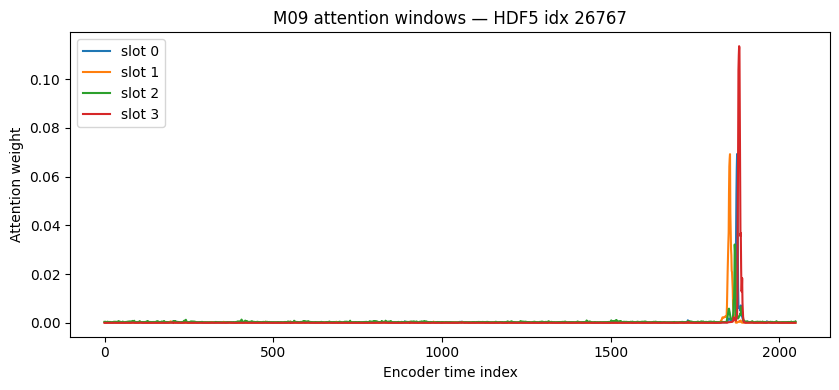

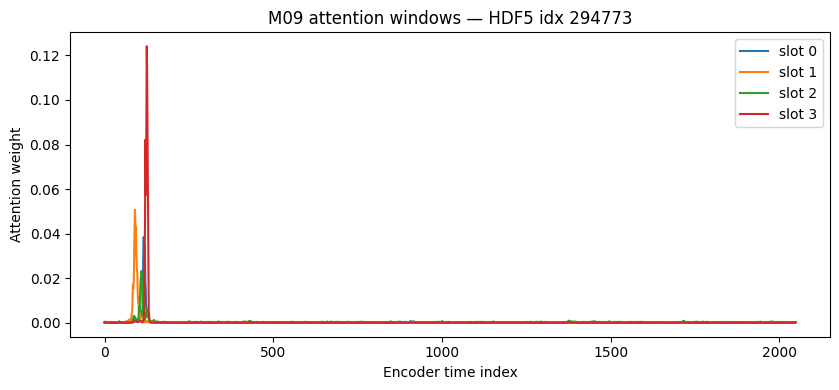

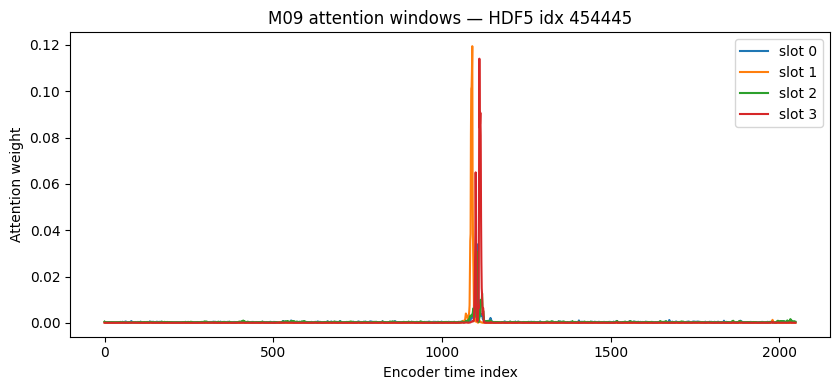

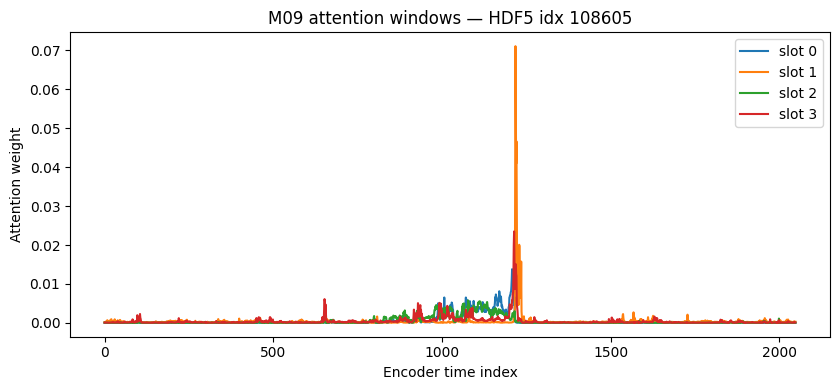

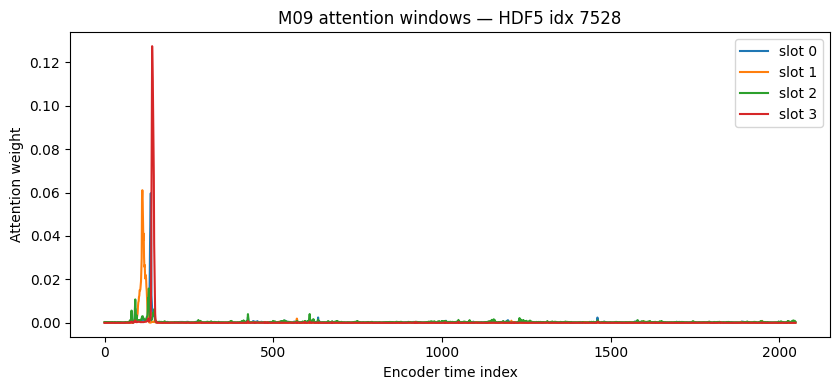

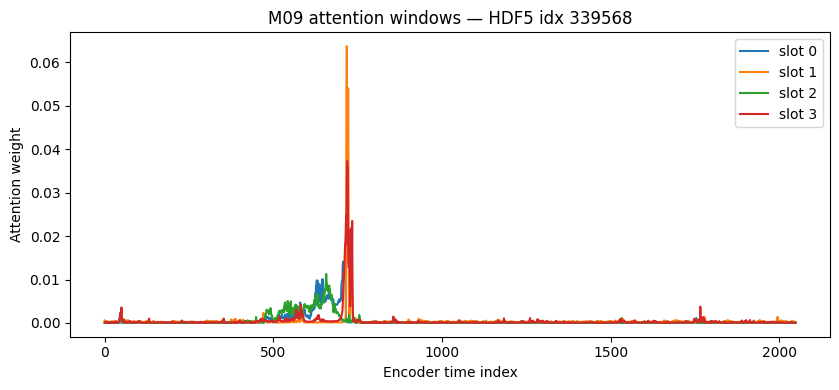

In [14]:
RUN_ATTENTION_DIAGNOSTIC = True

if RUN_ATTENTION_DIAGNOSTIC:
    import h5py
    import torch
    from src.models.network import SimpleCNN_ResidualDilatedMultiAttention

    dataset_path = PROCESSED_ROOT / DATASET_ID / f"{DATASET_ID}.h5"
    assert dataset_path.exists(), dataset_path

    m09_checkpoint = torch.load(RUNS["M09"]["checkpoint_path"], map_location="cpu")
    m09_model_config = m09_checkpoint.get("model_config", {})
    m09_kwargs = m09_model_config.get("model_kwargs", {})

    # Fallbacks if checkpoint metadata is incomplete.
    m09_kwargs.setdefault("n_detectors", 3)
    m09_kwargs.setdefault("n_outputs", 3)
    m09_kwargs.setdefault("embedding_dim", 64)
    m09_kwargs.setdefault("residual_channels", 64)
    m09_kwargs.setdefault("dilations", [1, 2, 4])
    m09_kwargs.setdefault("residual_kernel_size", 7)
    m09_kwargs.setdefault("dropout_conv", 0.05)
    m09_kwargs.setdefault("dropout_dense", 0.1)
    m09_kwargs.setdefault("num_groups", 8)
    m09_kwargs.setdefault("attention_slots", 4)
    m09_kwargs.setdefault("attention_hidden", 64)
    m09_kwargs.setdefault("attention_dropout", 0.0)
    m09_kwargs.setdefault("slot_dim", 32)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = SimpleCNN_ResidualDilatedMultiAttention(**m09_kwargs).to(device)
    model.load_state_dict(m09_checkpoint["model_state_dict"])
    model.eval()

    idx_test = ALIGNED["test"]["M09"]["idx"]
    rng = np.random.default_rng(123)
    selected_positions = rng.choice(len(idx_test), size=6, replace=False)
    selected_hdf5_idx = idx_test[selected_positions]

    with h5py.File(dataset_path, "r") as f:
        X = np.asarray(f["X"][np.sort(selected_hdf5_idx)], dtype=np.float32)

    x = torch.from_numpy(X).to(device)

    with torch.no_grad():
        features, attn = model.get_attention_weights(x)
        attn = attn.detach().cpu().numpy()

    for i, sample_idx in enumerate(selected_hdf5_idx):
        plt.figure(figsize=(8.5, 4.0))
        for k in range(attn.shape[1]):
            plt.plot(attn[i, k], label=f"slot {k}")
        plt.xlabel("Encoder time index")
        plt.ylabel("Attention weight")
        plt.title(f"M09 attention windows — HDF5 idx {sample_idx}")
        plt.legend()
        plt.tight_layout()
        plt.show()

else:
    print("Attention diagnostic disabled. Set RUN_ATTENTION_DIAGNOSTIC = True to run it.")

## 13. Decision table

In [15]:
decision_rows = []

for label in LABEL_NAMES:
    metric_row = test_difference_df.set_index("label").loc[label]
    slope_row = slope_delta_df.set_index("label").loc[label]

    q95 = test_quantile_df.query("label == @label and quantile == 0.95").iloc[0]
    q99 = test_quantile_df.query("label == @label and quantile == 0.99").iloc[0]

    boot_mse = bootstrap_df.query("label == @label and metric == 'MSE'").iloc[0]
    boot_mae = bootstrap_df.query("label == @label and metric == 'MAE'").iloc[0]

    decision_rows.append({
        "label": label,
        "MSE_delta_pct": metric_row["MSE_delta_pct"],
        "MAE_delta_pct": metric_row["MAE_delta_pct"],
        "R2_delta": metric_row["R2_delta"],
        "slope_delta": slope_row["slope_delta"],
        "std_ratio_delta": slope_row["std_ratio_delta"],
        "q95_abs_error_delta_pct": q95["M09_vs_M08_pct"],
        "q99_abs_error_delta_pct": q99["M09_vs_M08_pct"],
        "M09_win_rate": win_rate_df.set_index("label").loc[label, "M09_win_rate"],
        "bootstrap_MSE_ci95_low": boot_mse["ci95_low"],
        "bootstrap_MSE_ci95_high": boot_mse["ci95_high"],
        "bootstrap_MAE_ci95_low": boot_mae["ci95_low"],
        "bootstrap_MAE_ci95_high": boot_mae["ci95_high"],
    })

decision_df = pd.DataFrame(decision_rows)

display(global_difference_df)
display(decision_df)

,global_MSE_M08,global_MSE_M09,global_MSE_delta_pct,global_MAE_M08,global_MAE_M09,global_MAE_delta_pct
0,0.116352,0.113651,-2.321867,0.244785,0.241269,-1.436609


,label,MSE_delta_pct,MAE_delta_pct,R2_delta,slope_delta,std_ratio_delta,q95_abs_error_delta_pct,q99_abs_error_delta_pct,M09_win_rate,bootstrap_MSE_ci95_low,bootstrap_MSE_ci95_high,bootstrap_MAE_ci95_low,bootstrap_MAE_ci95_high
0,chirp_mass,-1.347565,-1.525661,0.001236,0.002141,0.001692,-0.642370,-0.371035,0.512200,-0.002538,-0.000020,-0.004435,-0.001961
1,total_mass,-3.687344,-2.513063,0.002720,0.005962,0.005041,-1.185166,-0.330339,0.521933,-0.003826,-0.001629,-0.006291,-0.003861
2,chi_eff,-2.261583,-0.705827,0.004147,-0.031817,-0.038600,-1.651254,0.331110,0.502133,-0.006629,-0.001577,-0.004282,-0.000192


## 14. Save tables

In [16]:
OUTPUT_DIR = RESULTS_ROOT / "evaluation_M08_vs_M09"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tables = {
    "metrics_all.csv": metrics_df,
    "global_metrics.csv": global_metrics_df,
    "test_differences.csv": test_difference_df,
    "global_test_difference.csv": global_difference_df,
    "slope_diagnostics.csv": slope_df,
    "slope_deltas.csv": slope_delta_df,
    "absolute_error_quantiles.csv": quantiles_df,
    "test_quantile_differences.csv": test_quantile_df,
    "paired_bootstrap.csv": bootstrap_df,
    "win_rates_and_disagreement.csv": win_rate_df,
    "training_summary.csv": history_summary_df,
    "decision_table.csv": decision_df,
}

if not checkpoint_df.empty:
    tables["checkpoint_metadata.csv"] = checkpoint_df

for filename, dataframe in tables.items():
    path = OUTPUT_DIR / filename
    dataframe.to_csv(path, index=False)
    print("Saved:", path)

Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/metrics_all.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/global_metrics.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/test_differences.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/global_test_difference.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/slope_diagnostics.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/slope_deltas.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/absolute_error_quantiles.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/test_quantile_differences.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/paired_bootstrap.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/win_rates_and_disagreement.csv
Saved: /data/vserrano/cbc_pe_data/results/evaluation_M08_vs_M09/training_summary.csv
Saved: /data/vserrano/cbc_pe_data/results/

## 15. True-vs-predicted density plots

These plots show the test-set density in physical units. The diagonal corresponds to perfect prediction.

Use them to inspect:

- regression to the mean;
- compression at the high/low ends of the parameter range;
- whether M09 changes the shape of the prediction cloud relative to M08;
- whether small metric gains correspond to visible structural improvements.


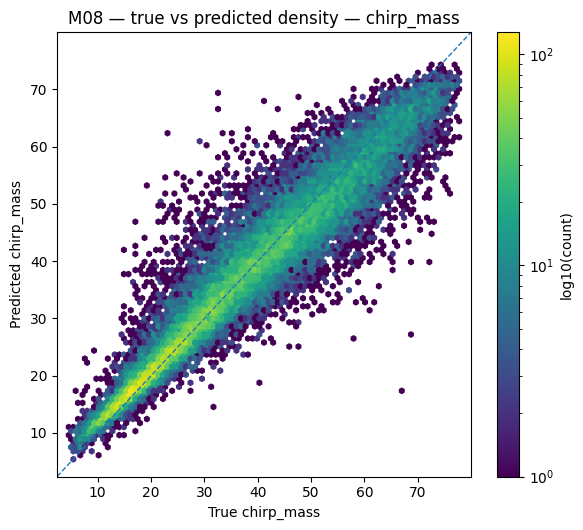

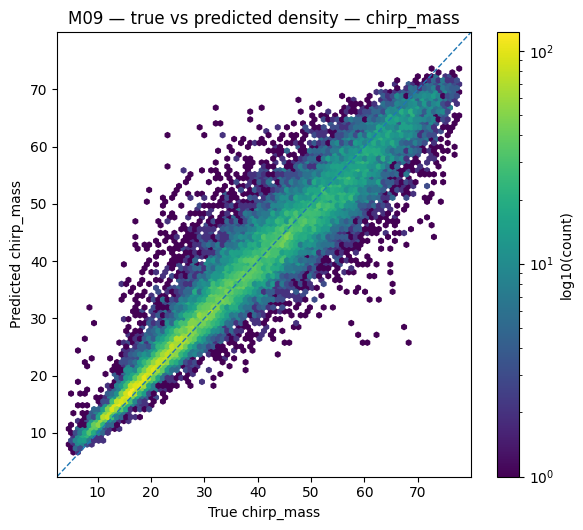

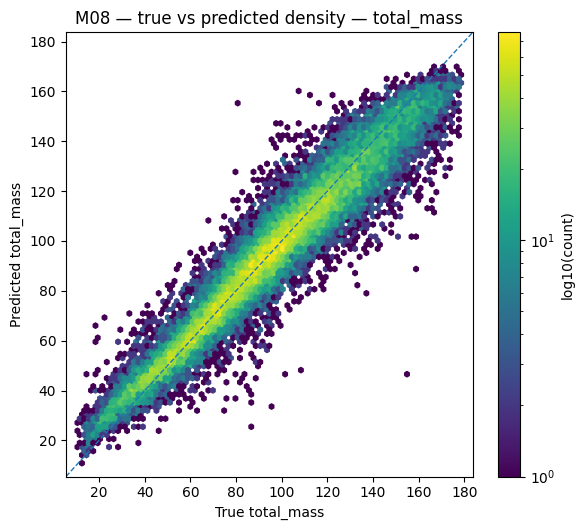

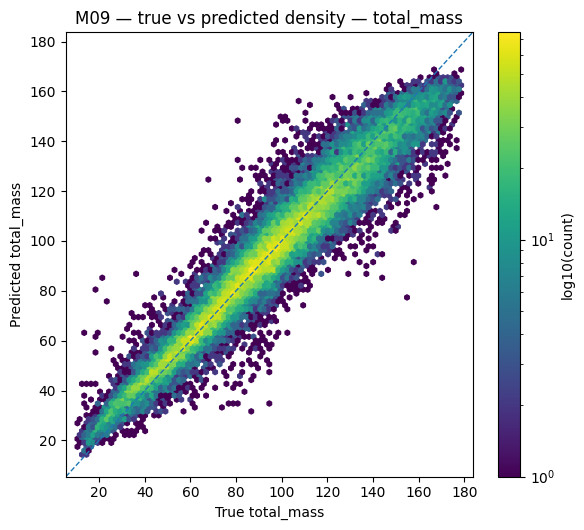

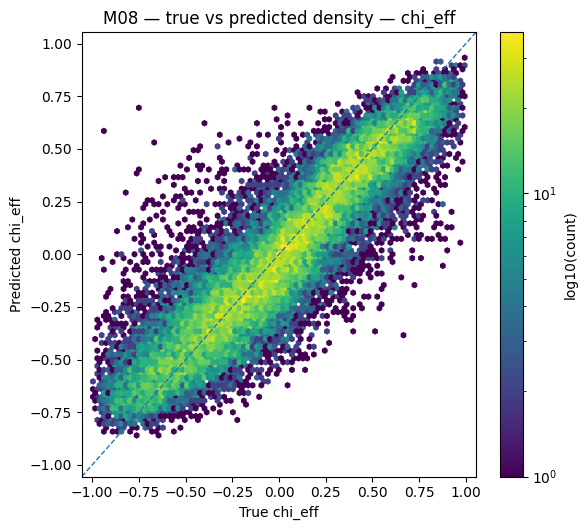

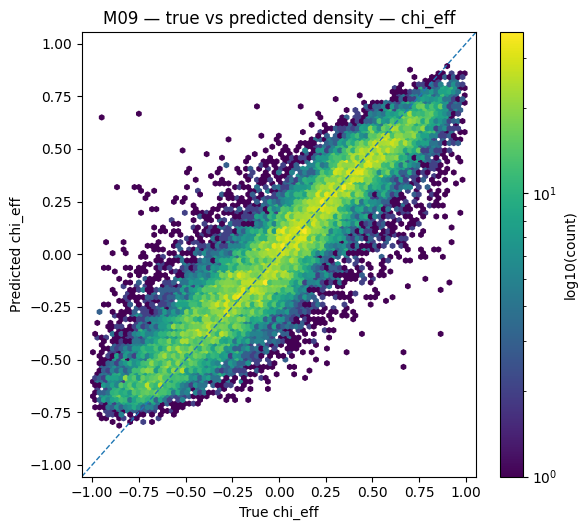

In [19]:
def plot_true_pred_density(
    y_true,
    y_pred,
    label,
    model_name,
    gridsize=80,
    mincnt=1,
):
    j = LABEL_NAMES.index(label)

    true = y_true[:, j]
    pred = y_pred[:, j]

    lo = min(np.min(true), np.min(pred))
    hi = max(np.max(true), np.max(pred))
    pad = 0.03 * (hi - lo)
    lo -= pad
    hi += pad

    plt.figure(figsize=(6.0, 5.4))
    hb = plt.hexbin(
        true,
        pred,
        gridsize=gridsize,
        mincnt=mincnt,
        bins="log",
    )
    plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.xlabel(f"True {label}")
    plt.ylabel(f"Predicted {label}")
    plt.title(f"{model_name} — true vs predicted density — {label}")
    plt.colorbar(hb, label="log10(count)")
    plt.tight_layout()
    plt.show()


y_true_test_phys = inverse_standardize(ALIGNED["test"]["M08"]["y"])

for label in LABEL_NAMES:
    for run_id in ["M08", "M09"]:
        y_pred_test_phys = inverse_standardize(ALIGNED["test"][run_id]["pred"])
        plot_true_pred_density(
            y_true=y_true_test_phys,
            y_pred=y_pred_test_phys,
            label=label,
            model_name=run_id,
            gridsize=85,
            mincnt=1,
        )


## 16. Residual density plots: pred - true vs true

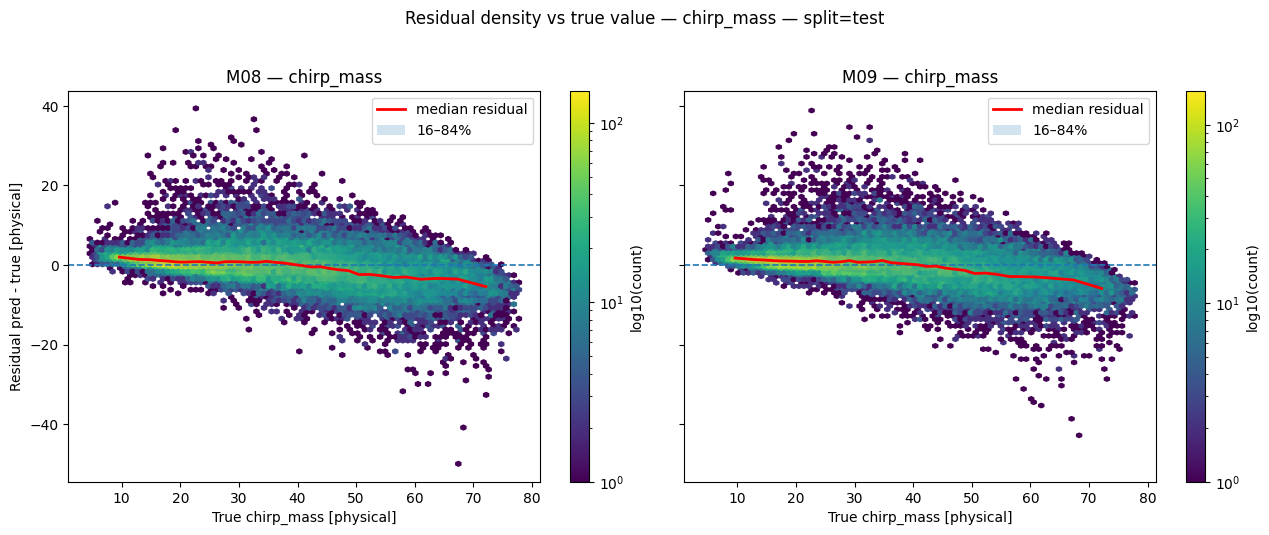

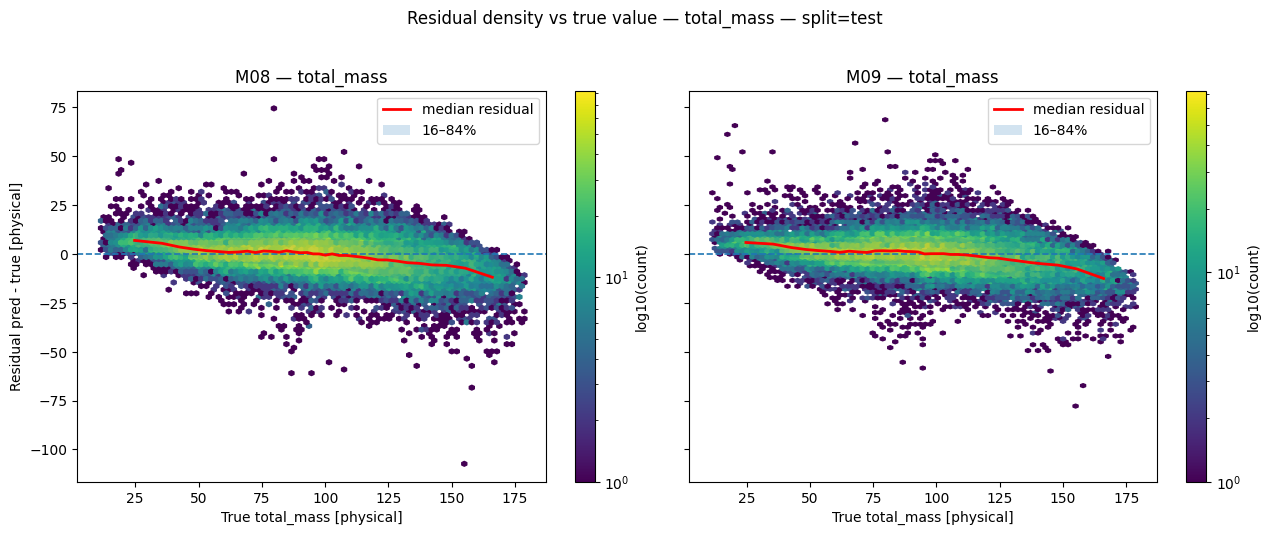

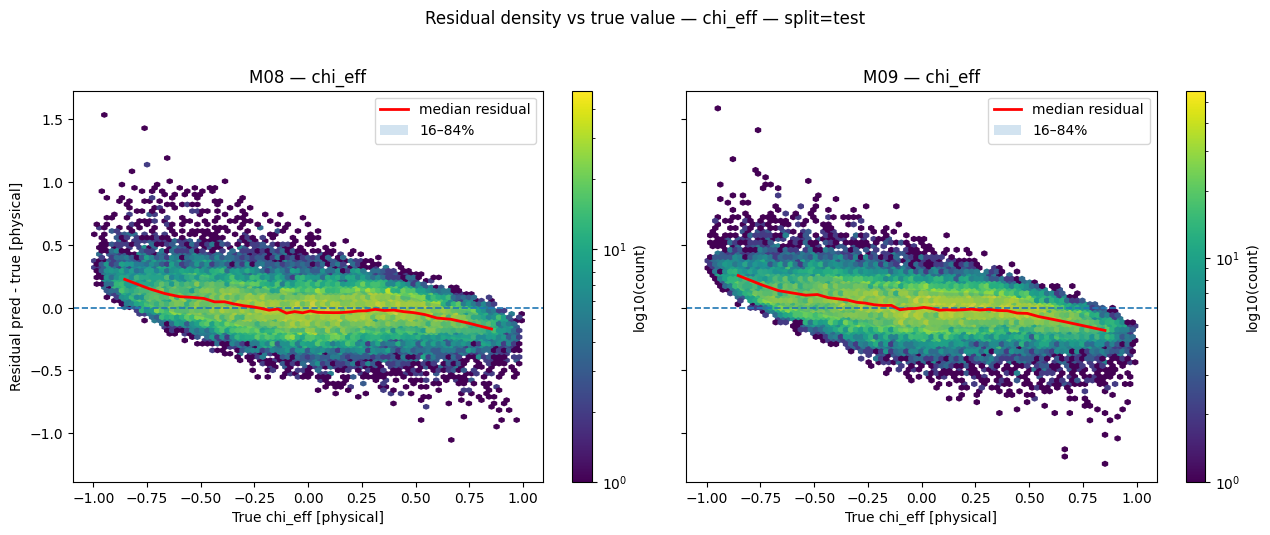

In [24]:


def plot_residual_density_by_true(
    run_ids=("M08", "M09"),
    split="test",
    physical_space=True,
    gridsize=80,
    trend_bins=35,
    mincnt=1,
):
    """
    Plot residual density:
        residual = prediction - truth
    against true physical/standardized target value.

    Interpretation
    --------------
    - y = 0 means no bias.
    - residual > 0 means overprediction.
    - residual < 0 means underprediction.
    - A sloped median residual curve indicates regression-to-the-mean.
    """

    for label_idx, label in enumerate(LABEL_NAMES):
        fig, axes = plt.subplots(
            1,
            len(run_ids),
            figsize=(6.5 * len(run_ids), 5.2),
            sharey=True,
        )

        if len(run_ids) == 1:
            axes = [axes]

        for ax, run_id in zip(axes, run_ids):
            y_true_std = ALIGNED[split][run_id]["y"][:, label_idx]
            y_pred_std = ALIGNED[split][run_id]["pred"][:, label_idx]

            if physical_space:
                y_true = y_true_std * y_std[label_idx] + y_mean[label_idx]
                y_pred = y_pred_std * y_std[label_idx] + y_mean[label_idx]
                unit = "physical"
            else:
                y_true = y_true_std
                y_pred = y_pred_std
                unit = "standardized"

            residual = y_pred - y_true

            hb = ax.hexbin(
                y_true,
                residual,
                gridsize=gridsize,
                bins="log",
                mincnt=mincnt,
            )

            fig.colorbar(
                hb,
                ax=ax,
                label="log10(count)",
            )

            ax.axhline(
                0.0,
                linestyle="--",
                linewidth=1.2,
            )

            # Median residual trend in true-value bins.
            edges = np.quantile(
                y_true,
                np.linspace(0.0, 1.0, trend_bins + 1),
            )
            edges = np.unique(edges)

            centers = []
            medians = []
            q16 = []
            q84 = []

            for left, right in zip(edges[:-1], edges[1:]):
                mask = (y_true >= left) & (y_true <= right)
                if mask.sum() < 20:
                    continue

                centers.append(np.median(y_true[mask]))
                medians.append(np.median(residual[mask]))
                q16.append(np.quantile(residual[mask], 0.16))
                q84.append(np.quantile(residual[mask], 0.84))

            centers = np.asarray(centers)
            medians = np.asarray(medians)
            q16 = np.asarray(q16)
            q84 = np.asarray(q84)

            ax.plot(
                centers,
                medians,
                linewidth=2.0,
                label="median residual",
                color="red"
            )

            ax.fill_between(
                centers,
                q16,
                q84,
                alpha=0.20,
                label="16–84%",

            )

            ax.set_xlabel(f"True {label} [{unit}]")
            ax.set_title(f"{run_id} — {label}")

            if ax is axes[0]:
                ax.set_ylabel(f"Residual pred - true [{unit}]")

            ax.legend()

        fig.suptitle(
            f"Residual density vs true value — {label} — split={split}",
            y=1.02,
        )
        plt.tight_layout()
        plt.show()


plot_residual_density_by_true(
    run_ids=("M08", "M09"),
    split="test",
    physical_space=True,
    gridsize=85,
    trend_bins=35,
)

## 17. Compact true-vs-predicted comparison tables

These tables quantify the visual pattern shown above: slope, dispersion ratio, and high-percentile absolute error.

In [20]:
true_pred_summary_cols = [
    "label",
    "slope_M08",
    "slope_M09",
    "slope_delta",
    "std_ratio_M08",
    "std_ratio_M09",
    "std_ratio_delta",
]

display(slope_delta_df[true_pred_summary_cols])

tail_summary = (
    test_quantile_df
    .query("quantile in [0.90, 0.95, 0.99]")
    .copy()
)

display(tail_summary)

,label,slope_M08,slope_M09,slope_delta,std_ratio_M08,std_ratio_M09,std_ratio_delta
0,chirp_mass,0.872785,0.874926,0.002141,0.915003,0.916695,0.001692
1,total_mass,0.893434,0.899396,0.005962,0.927534,0.932575,0.005041
2,chi_eff,0.811833,0.780016,-0.031817,0.898270,0.859670,-0.038600


run_id,label,quantile,M08,M09,M09_vs_M08_pct
1,chi_eff,0.900000,0.300427,0.298029,-0.798206
2,chi_eff,0.950000,0.379371,0.373106,-1.651254
3,chi_eff,0.990000,0.566387,0.568263,0.331110
5,chirp_mass,0.900000,8.031778,7.910862,-1.505463
6,chirp_mass,0.950000,10.439767,10.372705,-0.642370
7,chirp_mass,0.990000,17.008786,16.945677,-0.371035
9,total_mass,0.900000,15.019311,14.824495,-1.297106
10,total_mass,0.950000,19.126154,18.899477,-1.185166
11,total_mass,0.990000,29.286310,29.189566,-0.330339


## 18. Final decision

### Training behavior

M08 and M09 reach their best validation checkpoints at the same epoch, epoch 36, and both stop at epoch 61. M09 obtains a lower best validation loss:

- M08 best validation loss: 0.116116
- M09 best validation loss: 0.114245

This is a relative validation improvement of approximately 1.61%. However, M09 also ends with a lower final training loss than M08 while having a similar final validation loss. This suggests that the attention-pooling model has slightly higher effective capacity, but the validation gain is modest.

### Test performance

On the standardized test set, M09 improves the global metrics relative to M08:

- global MSE: 0.116352 → 0.113651, a 2.32% reduction;
- global MAE: 0.244785 → 0.241269, a 1.44% reduction.

The improvement is present for all three targets:

- chirp mass: MSE −1.35%, MAE −1.53%;
- total mass: MSE −3.69%, MAE −2.51%;
- effective spin: MSE −2.26%, MAE −0.71%.

The paired bootstrap intervals are below zero for all target-level MSE and MAE deltas, so the test-set improvement is statistically detectable under fixed trained models. The strongest target-level improvement is total mass.

However, the gain is small in practical terms. It is also smaller than the seed-to-seed variability observed for M08, where seed124 improved the global MSE by about 3.6% relative to M08 seed123. Therefore, M09 cannot yet be considered a clearly superior architecture from this single seed.

### Regression and contraction

For the mass parameters, M09 slightly improves the regression slopes and prediction dispersion:

- chirp-mass slope: 0.8728 → 0.8749;
- total-mass slope: 0.8934 → 0.8994.

This is favorable but small.

For effective spin, M09 reduces the slope and dispersion:

- chi_eff slope: 0.8118 → 0.7800;
- std(pred)/std(true): 0.8983 → 0.8597.

This is the main warning sign. M09 reduces the chi_eff MSE, but it does so while producing a more compressed prediction distribution. The MAE gain is also small for chi_eff, and the q99 absolute-error quantile slightly worsens. This suggests that M09 may be smoothing or regularizing the effective-spin predictions rather than learning a substantially richer temporal representation.

### Error tails

M09 improves most physical absolute-error quantiles, but the tail improvements are modest:

- chirp mass q95: −0.64%, q99: −0.37%;
- total mass q95: −1.19%, q99: −0.33%;
- chi_eff q95: −1.65%, q99: +0.33%.

Thus, M09 does not produce a strong reduction of difficult-event tails. The q99 degradation for chi_eff is small, but it reinforces the point that the attention pooling is not obviously solving the hardest effective-spin cases.

### Attention-window diagnostic

The attention windows are not completely trivial. The four windows often concentrate on different encoder-time regions, and at least one window frequently forms a sharper peak that may plausibly correspond to the high-information part of the signal, such as the merger/ringdown region.

This is useful diagnostically: the model is using the attention mechanism in a non-uniform way. However, the metric gains indicate that this extra temporal selection is not translating into a large improvement in parameter estimation. A plausible interpretation is that the residual dilated encoder already extracts most of the relevant temporal information before pooling, so replacing average pooling with multi-slot attention only gives a small refinement.

### Adoption decision

M09 should not replace M08 as the operational baseline yet.

The result is best interpreted as a positive but marginal pooling ablation:

1. M09 improves global test MSE and MAE relative to M08 seed123.
2. The improvement is consistent across targets and statistically detectable on the fixed test set.
3. The practical gain is small.
4. The gain is smaller than the previously observed M08 seed-to-seed variability.
5. M09 worsens the effective-spin slope and prediction dispersion.
6. The high-error tails improve only weakly and chi_eff q99 slightly worsens.
7. The attention windows are interpretable, but they do not provide evidence of a major new performance regime.

Therefore, M08 remains the current operational baseline. M09 should be retained as an informative ablation showing that learned temporal pooling can provide a small improvement, especially for total mass, but not enough to justify replacing M08 without additional evidence.

### Recommended next steps

The next priority should not be another pooling variant immediately. The evidence suggests that pooling is not the dominant bottleneck once the residual dilated encoder is in place.

Recommended sequence:

1. Keep M08 as the baseline for the main Mondrian/conformal analysis.
2. Optionally evaluate M09 with Mondrian only after the M08/M00 conformal story is finalized.
3. If M09 is pursued further, run a second seed before making architectural claims.
4. Inspect attention windows in relation to physical quantities: merger location, mass, signal duration, SNR, and residual size.
5. If searching for a larger architecture gain, test a deeper non-causal TCN or a richer residual-dilated encoder rather than more pooling-only variants.

The current conclusion is that M09 is scientifically useful, but not operationally decisive.


_____________________________________

In [26]:
# ============================================================
# Inspect HDF5 / metadata availability
# ============================================================

import h5py
import json
from pathlib import Path

dataset_path = PROCESSED_ROOT / DATASET_ID / f"{DATASET_ID}.h5"

print("dataset_path:", dataset_path)
print("exists:", dataset_path.exists())

with h5py.File(dataset_path, "r") as f:
    print("\nTop-level keys:")
    for key in f.keys():
        obj = f[key]
        if hasattr(obj, "shape"):
            print(f"  {key:30s} shape={obj.shape} dtype={obj.dtype}")
        else:
            print(f"  {key:30s} group")

    print("\nAttrs:")
    for key, value in f.attrs.items():
        print(f"  {key}: {value}")

# Try to locate external metadata JSON files.
metadata_candidates = sorted(PROCESSED_ROOT.glob(f"{DATASET_ID}*metadata*.json"))

print("\nMetadata JSON candidates:")
if metadata_candidates:
    for path in metadata_candidates:
        print(" ", path)
else:
    print("  No metadata JSON found with this pattern.")

dataset_path: /data/vserrano/cbc_pe_data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000.h5
exists: True

Top-level keys:
  X                              shape=(500000, 3, 16384) dtype=float32
  generation                     group
  injection                      group
  parameters                     group
  placement                      group
  projection                     group
  snr                            group
  windowing                      group
  y                              shape=(500000, 3) dtype=float32

Attrs:
  chunk_size: 2500
  dataset_status: complete
  detector_names: ["H1", "L1", "V1"]
  duration: 4.0
  label_names: ["chirp_mass", "total_mass", "chi_eff"]
  length: 16384
  low_frequency_cutoff: 30.0
  num_samples: 500000
  num_written: 500000
  placement_policy: random_contained
  processing_context_end_samples: 1664
  processing_context_start_samples: 1664
  processing_length: 19712
  sampling_freque

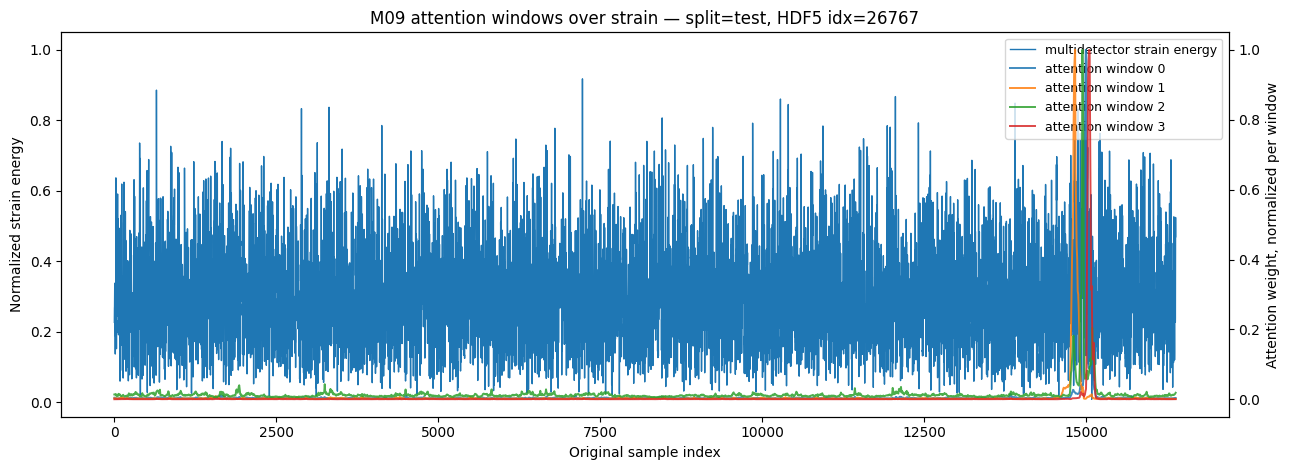

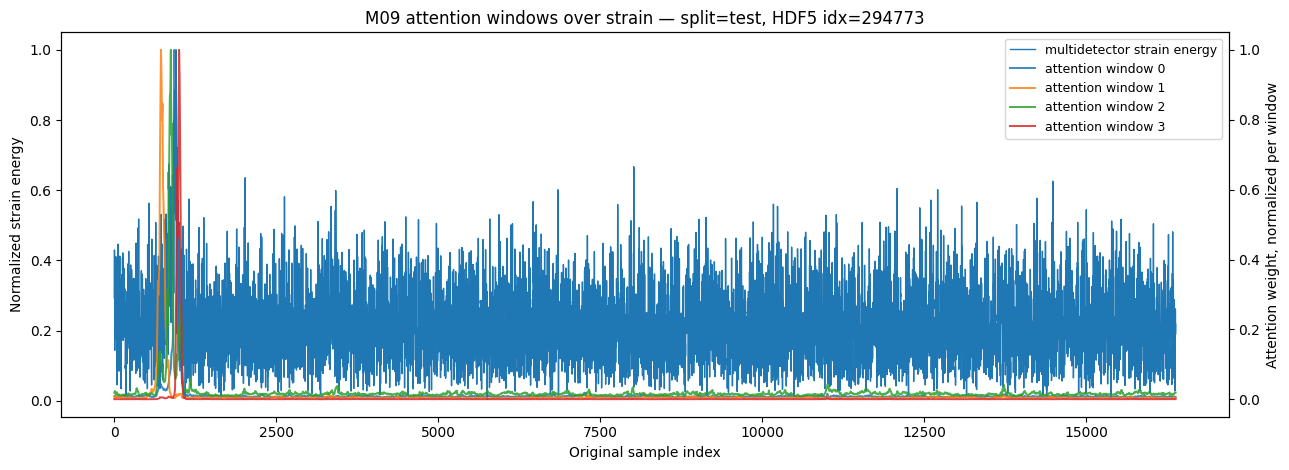

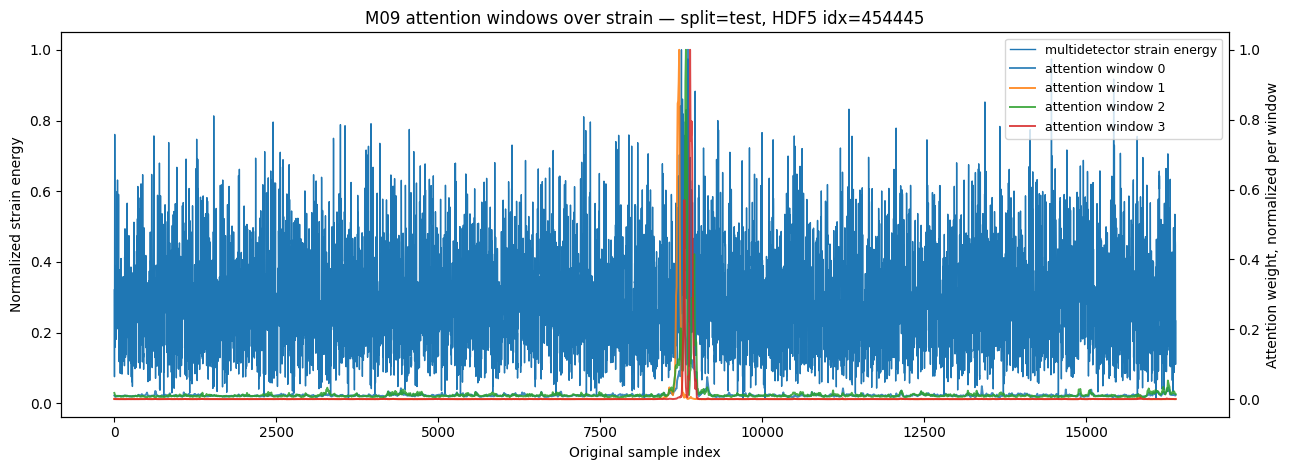

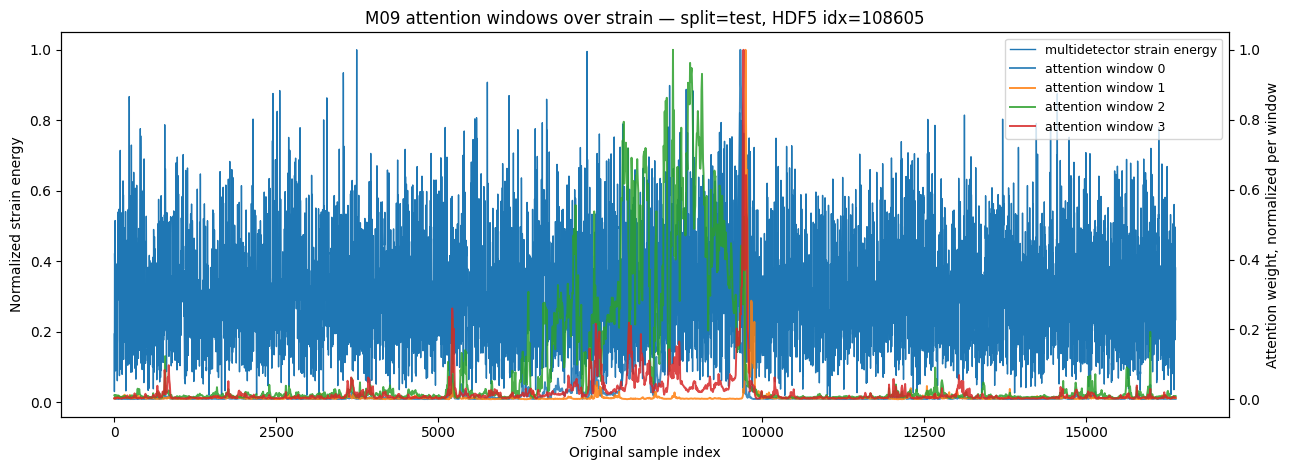

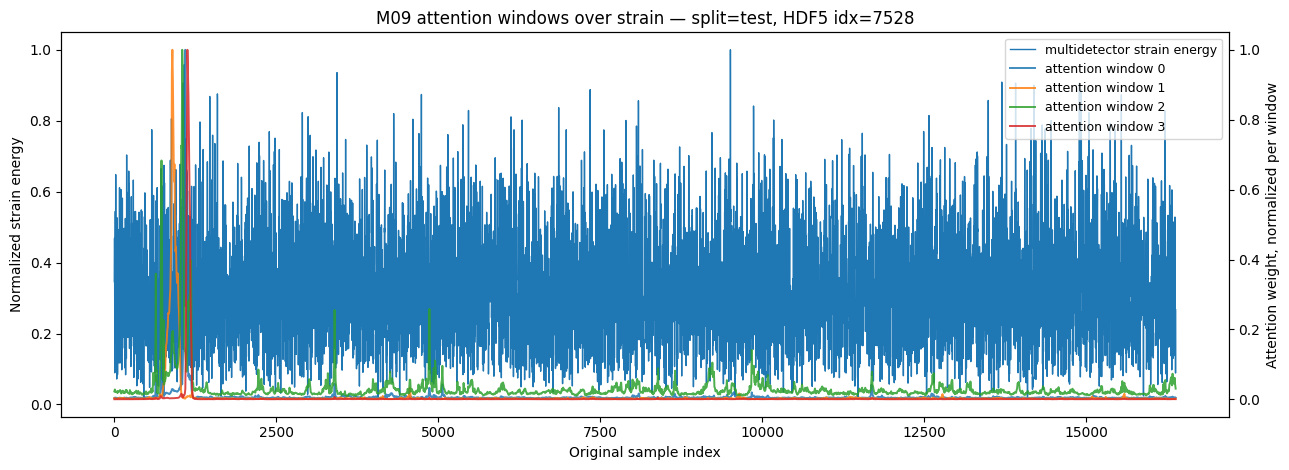

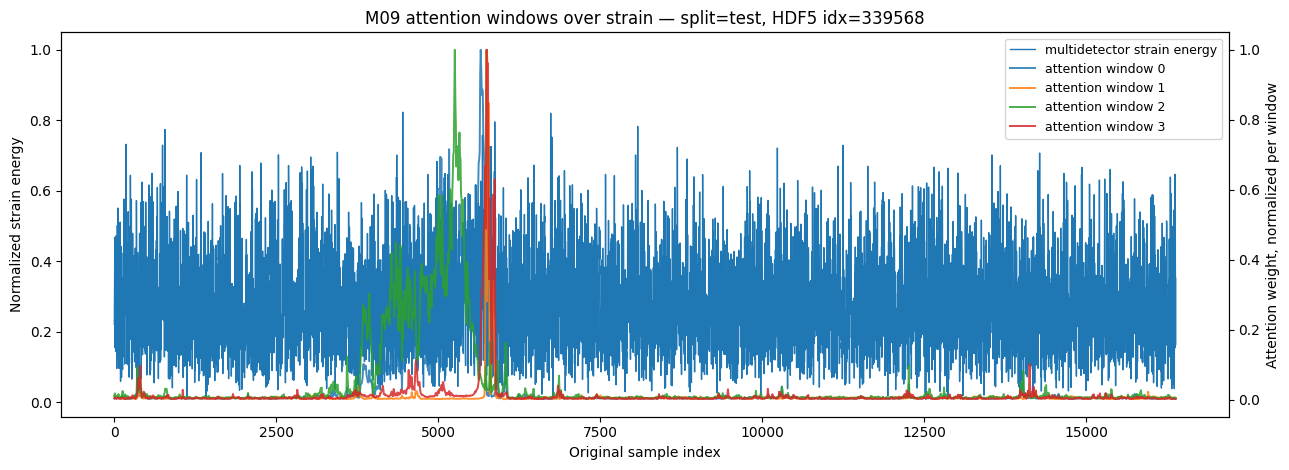

In [31]:
# ============================================================
# Attention windows over strain energy
# ============================================================

import h5py
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.models.network import SimpleCNN_ResidualDilatedMultiAttention

def load_m09_model_from_checkpoint():
    checkpoint = torch.load(
        RUNS["M09"]["checkpoint_path"],
        map_location="cpu",
    )

    model_config = checkpoint.get("model_config", {})
    model_kwargs = model_config.get("model_kwargs", {})

    # Fallbacks, in case older checkpoint metadata is incomplete.
    model_kwargs.setdefault("n_detectors", 3)
    model_kwargs.setdefault("n_outputs", 3)
    model_kwargs.setdefault("embedding_dim", 64)
    model_kwargs.setdefault("residual_channels", 64)
    model_kwargs.setdefault("dilations", [1, 2, 4])
    model_kwargs.setdefault("residual_kernel_size", 7)
    model_kwargs.setdefault("dropout_conv", 0.05)
    model_kwargs.setdefault("dropout_dense", 0.1)
    model_kwargs.setdefault("num_groups", 8)
    model_kwargs.setdefault("attention_slots", 4)
    model_kwargs.setdefault("attention_hidden", 64)
    model_kwargs.setdefault("attention_dropout", 0.0)
    model_kwargs.setdefault("slot_dim", 32)

    model = SimpleCNN_ResidualDilatedMultiAttention(**model_kwargs)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return model


def attention_to_signal_grid(attention_weights, signal_length):
    """
    Map encoder attention indices to original signal sample indices.

    attention_weights: shape (K, T_encoder)
    returns:
        original_sample_grid: shape (T_encoder,)
    """
    n_encoder = attention_weights.shape[-1]

    # Proportional mapping. This is not an exact receptive-field map,
    # but it is good enough for visual alignment.
    original_grid = np.linspace(
        0,
        signal_length - 1,
        n_encoder,
    )

    return original_grid


def plot_attention_windows_on_signal(
    sample_positions,
    split="test",
    run_id="M09",
    max_samples=6,
    normalize_signal=True,
):
    """
    Plot multichannel strain energy and M09 attention windows.

    sample_positions are positions inside the aligned split arrays,
    not raw HDF5 indices.
    """

    dataset_path = PROCESSED_ROOT / DATASET_ID / f"{DATASET_ID}.h5"
    assert dataset_path.exists(), dataset_path

    model = load_m09_model_from_checkpoint()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    idx_split = ALIGNED[split][run_id]["idx"]
    sample_positions = list(sample_positions)[:max_samples]
    hdf5_indices = idx_split[sample_positions]

    with h5py.File(dataset_path, "r") as f:
        X = np.asarray(f["X"][np.sort(hdf5_indices)], dtype=np.float32)

    x_tensor = torch.from_numpy(X).to(device)

    with torch.no_grad():
        features, attention = model.get_attention_weights(x_tensor)

    attention = attention.detach().cpu().numpy()

    for local_i, hdf5_idx in enumerate(hdf5_indices):
        strain = X[local_i]  # (detectors, time)
        n_detectors, signal_length = strain.shape

        # Energy-like multichannel summary.
        energy = np.sqrt(np.mean(strain**2, axis=0))

        if normalize_signal:
            denom = np.max(np.abs(energy))
            if denom > 0:
                energy_plot = energy / denom
            else:
                energy_plot = energy
        else:
            energy_plot = energy

        attn = attention[local_i]  # (K, T_encoder)
        original_grid = attention_to_signal_grid(
            attn,
            signal_length=signal_length,
        )

        fig, ax1 = plt.subplots(figsize=(13.0, 4.8))

        time_samples = np.arange(signal_length)

        ax1.plot(
            time_samples,
            energy_plot,
            linewidth=1.0,
            label="multidetector strain energy",
        )

        ax1.set_xlabel("Original sample index")
        ax1.set_ylabel("Normalized strain energy")
        ax1.set_title(
            f"M09 attention windows over strain — split={split}, HDF5 idx={hdf5_idx}"
        )

        ax2 = ax1.twinx()

        for k in range(attn.shape[0]):
            weights = attn[k]

            # Rescale each attention window for visibility.
            w = weights / np.max(weights) if np.max(weights) > 0 else weights

            ax2.plot(
                original_grid,
                w,
                linewidth=1.4,
                alpha=0.85,
                label=f"attention window {k}",
            )

        ax2.set_ylabel("Attention weight, normalized per window")

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()

        ax1.legend(
            lines1 + lines2,
            labels1 + labels2,
            loc="upper right",
            fontsize=9,
        )

        plt.tight_layout()
        plt.show()


# Example: random test samples.
rng = np.random.default_rng(123)
sample_positions = rng.choice(
    len(ALIGNED["test"]["M09"]["idx"]),
    size=6,
    replace=False,
)

plot_attention_windows_on_signal(
    sample_positions=sample_positions,
    split="test",
    run_id="M09",
    max_samples=6,
)

In [32]:
# ============================================================
# Helper: try to read event-level metadata arrays from HDF5
# ============================================================

def read_optional_hdf5_fields(hdf5_indices, candidate_keys):
    """
    Try to read event-level arrays from the HDF5 file.

    Returns a dictionary with keys that exist.
    """
    found = {}

    with h5py.File(dataset_path, "r") as f:
        for key in candidate_keys:
            if key in f:
                try:
                    found[key] = np.asarray(f[key][hdf5_indices])
                    print(f"Loaded {key}: shape={found[key].shape}")
                except Exception as exc:
                    print(f"Could not load {key}: {type(exc).__name__}: {exc}")

    return found


candidate_metadata_keys = [
    "signal_start_index",
    "signal_end_index",
    "injection_start_index",
    "injection_end_index",
    "peak_index",
    "merger_index",
    "snr",
    "network_snr",
    "mass_1",
    "mass_2",
    "chirp_mass",
    "total_mass",
    "chi_eff",
]

# Example:
idx_split = ALIGNED["test"]["M09"]["idx"]
example_positions = sample_positions
example_hdf5_indices = idx_split[example_positions]

event_metadata = read_optional_hdf5_fields(
    hdf5_indices=example_hdf5_indices,
    candidate_keys=candidate_metadata_keys,
)

event_metadata.keys()

Could not load snr: TypeError: Accessing a group is done with bytes or str, not <class 'numpy.ndarray'>


dict_keys([])

In [33]:
# ============================================================
# Attention window centers and effective widths
# ============================================================

def compute_attention_window_stats(attention):
    """
    attention: array with shape (B, K, T)

    Returns DataFrame with center and width per sample/window.
    """
    B, K, T = attention.shape
    grid = np.arange(T)

    rows = []

    for i in range(B):
        for k in range(K):
            w = attention[i, k]
            w = w / np.sum(w)

            center = np.sum(w * grid)
            width = np.sqrt(np.sum(w * (grid - center) ** 2))
            entropy = -np.sum(w * np.log(w + 1e-12))
            peak = np.argmax(w)

            rows.append({
                "sample_position": i,
                "window": k,
                "center_encoder_index": center,
                "width_encoder_index": width,
                "peak_encoder_index": peak,
                "entropy": entropy,
            })

    return pd.DataFrame(rows)


# Example using the same selected samples from the previous diagnostic.
# Requires variable `attention` from the diagnostic cell.
# attention_stats_df = compute_attention_window_stats(attention)
# display(attention_stats_df)